In [2]:
import os
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
eyetraker_support = np.array('0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 1 1'.split(' ')).astype(int)
subjects = ['01TG', '02ES', '03AC', '04AB', '06KK', '07TS', '10AS', '11AK',
       '13AU', '14BE', '15AZ', '18KK', '19VB', '20EC', '21EC', '22ES',
       '23MM', '25PP']
eyetraker_support = dict(zip(subjects, eyetraker_support))

In [4]:
coef_d = {'support': (0.365 * 180 / np.pi)/960, 'no_support': (0.268 * 180 / np.pi)/960}

# process files

500 Hz

In [166]:
filename = r'..\data\results\game_dataset.csv'
df = pd.read_csv(filename)
df.rename(columns={'mode': 'condition'}, inplace=True)

In [193]:
df.loc[(df.filename.isin(['im_log_game_4', 'qm_log_game_4']))]['subject'].unique()

array(['06KK', '07TS', '10AS', '13AU', '21EC', '24EK', '25PP'],
      dtype=object)

In [390]:
def redefine_timestamps(timestamps):
    time_list = []
    for time in timestamps:
        curr_time = time[0]//1000000
        time_list.extend(np.arange(curr_time-40, curr_time, 2))
    return np.array(time_list, dtype=np.int64)

In [468]:
subj = '06KK'
mode = 'im'
n_game = '1'
filename = f'{mode}_rec_game_{n_game}.hdf'
filename_log = f'{mode}_log_game_{n_game}'
with h5py.File(os.path.join(r'..\data\raw\exp', subj, filename), 'r') as h5f:
    coords = (h5f['eyeData/data'][:-1])[:, :2]
    timestamps = redefine_timestamps(h5f['eyeData/blocks'][:])
    raw_events =  h5f['eyeEvents/messages'][:]

In [469]:
import json
# функция для доставания глазодвигательных событий (фиксаций, саккад и морганий)
def get_event(event):
    mes = str(event)[2:-1]
    res_new = mes.replace('\\n', '')
    res_new = res_new.replace(' ', '')
    res_new = res_new.replace("\\", ' ')
    event = json.loads(res_new)
    return event

# функция для создания из набора сообщений о глазодвигательных событиях датасета
def parse_event(event):
    event_type = event['type'][:event['type'].find('_')]
    if event_type == 'blink':
        event_parsed = {
            'event': event_type, 
            'time_start': event['start_time'],
            'time_end': event['end_time']
        }
    elif event_type == 'saccade':
        try:
            event_parsed = {
                'event': event_type, 
                'time_start': event['start_time'],
                'time_end': event['end_time'],
                'x_start': event['gaze']['start']['x'],
                'y_start': event['gaze']['start']['y'],
                'x_stop': event['gaze']['stop']['x'],
                'y_stop': event['gaze']['stop']['y'],
            }
        except:  # just a very strange bug
            event_parsed = {
                'event': event_type, 
                'time_start': event['start_time'],
                'time_end': event['end_time'],
                'x_start': event['gaze']['start']['x'],
                'y_start': event['gaze']['start']['y'],
                'x_stop':  np.nan,
                'y_stop': np.nan,
            }
    else:
        event_parsed = {
            'event': event_type, 
            'time_start': event['start_time'],
            'time_end': event['end_time'],
            'x_average': event['gaze']['average']['x'],
            'y_average': event['gaze']['average']['y']
        }
    return event_parsed

def create_df_events(filename):
    with h5py.File(filename, 'r') as h5f:
        df_fix = pd.DataFrame({
            'time_start': h5f['A/Events/Efix/start'][:][0],
            'time_end': h5f['A/Events/Efix/end'][:][0],
            'x_average': h5f['A/Events/Efix/posX'][:][0],
            'y_average': h5f['A/Events/Efix/posY'][:][0],
        }).round(2)
        df_fix['event'] = 'fixation'
        
        df_sac = pd.DataFrame({
            'time_start': h5f['A/Events/Esacc/start'][:][0],
            'time_end': h5f['A/Events/Esacc/end'][:][0],
            'x_start': h5f['A/Events/Esacc/posX'][:][0],
            'y_start': h5f['A/Events/Esacc/posY'][:][0],
            'x_stop': h5f['A/Events/Esacc/posXend'][:][0],
            'y_stop': h5f['A/Events/Esacc/posYend'][:][0],
        }).round(2)
        df_sac['event'] = 'saccade'
    return pd.concat([df_fix, df_sac], ignore_index=True)

In [470]:
events = [get_event(event[2]) for event in raw_events]
times = [int(event[0]//1000000) for event in raw_events]
# print(events)
df_events = [parse_event(event) for event in events if event['type'].find('start') == -1]
df_events = pd.DataFrame(df_events).round()
times = [timestamp for i, timestamp in enumerate(times) if events[i]['type'].find('start') == -1]
df_events['res_start'] = times - (df_events['time_end'] - df_events['time_start'])
df_events['res_end'] = times
df_events['diff'] = df_events['res_end'] - df_events['time_end']

diff = df_events['diff'].mean().round()

filename_rec = f'{mode}_EyeLink_game_{filename_log[-1:]}_reparsed.h5'
df_events = create_df_events((os.path.join(r'..\data\raw\exp', subj, filename_rec)))
df_events['res_start'] = df_events['time_start'] + diff
df_events['res_end'] = df_events['time_end'] + diff

<Axes: xlabel='dur', ylabel='Count'>

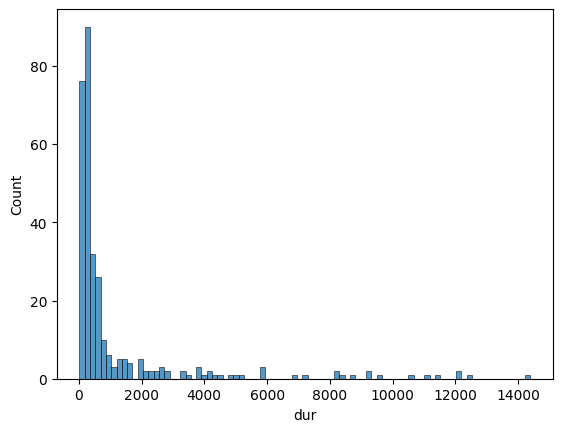

In [471]:
df_events['dur'] = df_events['time_end'] - df_events['time_start']
sns.histplot(df_events.loc[df_events.event == 'fixation'], x='dur')
# plt.xlim(0, 1000)

In [472]:
df_events.loc[df_events.dur > 5000]

,time_start,time_end,x_average,y_average,event,x_start,y_start,x_stop,y_stop,res_start,res_end,dur
13,91274.0,105662.0,629.9,432.0,fixation,NaN,NaN,NaN,NaN,79816204.0,79830592.0,14388.0
18,108598.0,118096.0,849.5,688.3,fixation,NaN,NaN,NaN,NaN,79833528.0,79843026.0,9498.0
32,126526.0,138692.0,1341.1,942.1,fixation,NaN,NaN,NaN,NaN,79851456.0,79863622.0,12166.0
37,141856.0,152974.0,1089.2,436.7,fixation,NaN,NaN,NaN,NaN,79866786.0,79877904.0,11118.0
43,160056.0,165974.0,1316.6,245.9,fixation,NaN,NaN,NaN,NaN,79884986.0,79890904.0,5918.0
70,196156.0,201214.0,767.6,907.2,fixation,NaN,NaN,NaN,NaN,79921086.0,79926144.0,5058.0
71,201258.0,207146.0,716.1,961.5,fixation,NaN,NaN,NaN,NaN,79926188.0,79932076.0,5888.0
80,210300.0,218476.0,1246.2,662.2,fixation,NaN,NaN,NaN,NaN,79935230.0,79943406.0,8176.0
86,226672.0,235332.0,1053.4,851.1,fixation,NaN,NaN,NaN,NaN,79951602.0,79960262.0,8660.0
109,257218.0,264440.0,548.2,793.3,fixation,NaN,NaN,NaN,NaN,79982148.0,79989370.0,7222.0


(np.float64(511.7450256347656),
 np.float64(779.1549987792969),
 np.float64(445.64500579833987),
 np.float64(829.655012512207))

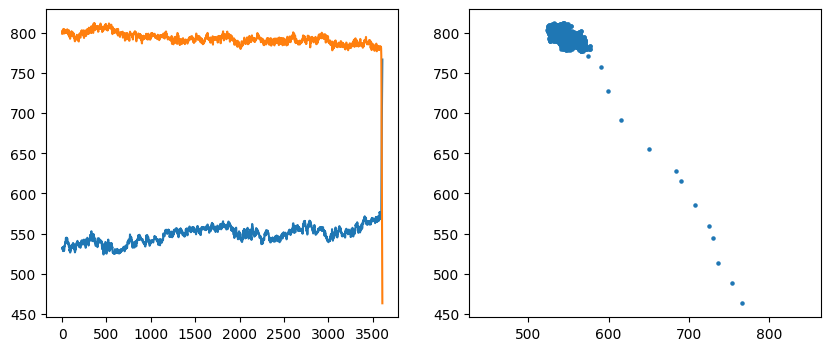

In [476]:
i = 109
curr_coords = define_coords(coords, timestamps, df_events.iloc[i]['res_end'],  df_events.iloc[i]['dur'])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(curr_coords)
ax[1].scatter(curr_coords[:, 0], curr_coords[:, 1], s=5)
# circle1 = plt.Circle((664, 429), 100, color='r', fill=False)
# ax[1].add_patch(circle1)
ax[1].axis('equal')

In [426]:
df_events.iloc[i]['res_end'], timestamps, curr_coords

(np.float64(686202828.0),
 array([686008065, 686008067, 686008069, ..., 686308736, 686308738,
        686308740]),
 array([[nan, nan],
        [nan, nan],
        [nan, nan],
        ...,
        [nan, nan],
        [nan, nan],
        [nan, nan]]))

In [256]:
df_subj = df.loc[(df.subject == subj) & (df.filename == filename_log)].reset_index()

In [257]:
df_subj.loc[df_subj.res_timestamp == 79818195]

,index,event,timestamp,pos_x,pos_y,res_timestamp,decision,earned_points,total_points,game_timestamp,condition,n_game,subject,filename,n_star
2,7564,activate_star,6958,664,429,79818195,-,0,0,2579,im,1,06KK,im_log_game_1,3


In [209]:
def define_coords(all_coords, timestamps, timestamp_end, duration=1000):
    return all_coords[np.where((timestamps > timestamp_end-duration) & (timestamps < timestamp_end))[0]]

def calculate_deviation(coords_gaze, pos_center):
    x_dev = coords_gaze[:, 0] - pos_center[0]
    y_dev = coords_gaze[:, 1] - pos_center[1]
    
    dev = np.sqrt(x_dev ** 2 + y_dev ** 2)
    return np.nanmedian(dev).round(2)

def calculate_variance(coords):
    return np.nanvar(coords).round(2)

def calculate_range(coords):
    return (np.nanmax(coords) - np.nanmin(coords)).round(2)

# analysis

## selection phase: heatmap

### developing

In [59]:
subjects = os.listdir(r'..\data\raw\exp')
df_activation = [[] for _ in range(8)]
for i in range(8):
    for subject in subjects:
        filename = os.path.join(r'..\data\results\gaze_features', f'{subject}_{i}_activ.csv')
        df_activation[i].append(pd.read_csv(filename))
    df_activation[i] = pd.concat(df_activation[i], ignore_index=True)

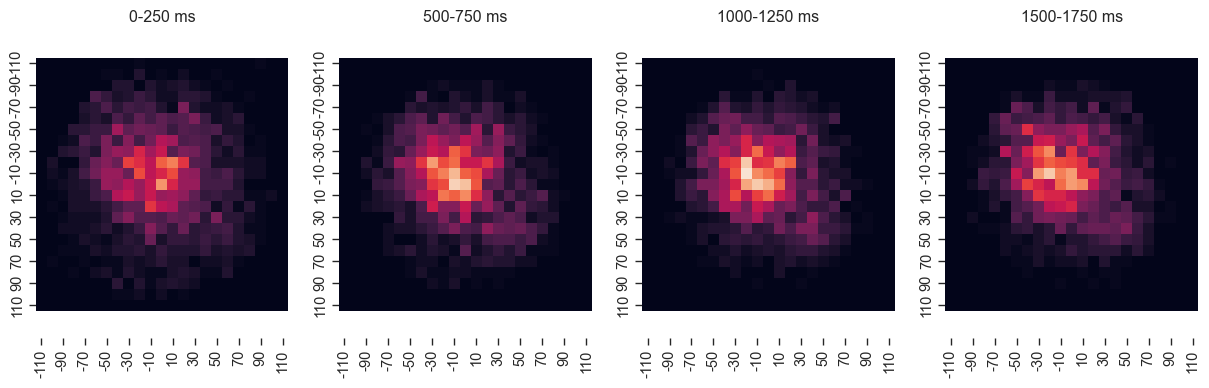

In [ ]:
# no correction
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for k in range(0, 8, 2):
    df_activ = df_activation[k]
    df_activ['x_norm'] = df_activ['gaze_pos_x'] - df_activ['pos_x']
    df_activ['y_norm'] = df_activ['gaze_pos_y'] - df_activ['pos_y']
    df_map = pd.DataFrame()
    step = 10
    for i in range(-110, 111, step):
        df_map[f'{i}'] = np.zeros(int(110*2//step+1))
    df_map.set_index(np.arange(-110, 111, step), inplace=True)

    x_pos = df_activ['x_norm'].values
    y_pos = df_activ['y_norm'].values
    for i in range(-110, 111, step):
        for j in range(-110, 111, step):
            df_map.loc[df_map.index == j, f'{i}'] = np.where((x_pos >= i-step//2) & (x_pos < i+step//2) & (y_pos >= j-step//2) & (y_pos < j+step//2))[0].shape[0]
    draw_cbar = False if k <= 7 else True
    sns.heatmap(df_map, ax=axes[k//2], vmin=0, vmax=45, cbar=draw_cbar)
    axes[k//2].axis('equal')
    axes[k//2].set_title(f'{k*250}-{k*250+250} ms')

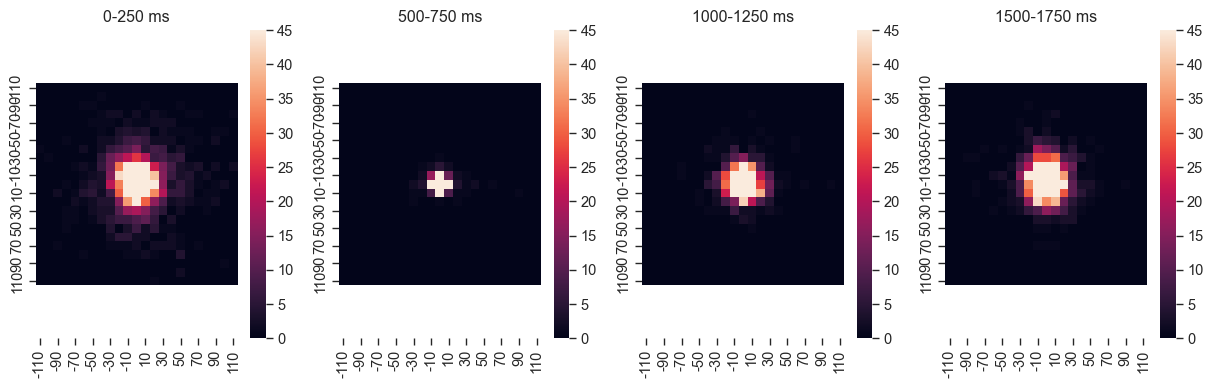

In [68]:
# correction format 1
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for k in range(0, 8, 2):
    df_activ = df_activation[k]
    df_activ['x_norm'] = df_activ['gaze_pos_x'] - df_activ['av_x']
    df_activ['y_norm'] = df_activ['gaze_pos_y'] - df_activ['av_y']
    df_map = pd.DataFrame()
    step = 10
    for i in range(-110, 111, step):
        df_map[f'{i}'] = np.zeros(int(110*2//step+1))
    df_map.set_index(np.arange(-110, 111, step), inplace=True)

    x_pos = df_activ['x_norm'].values
    y_pos = df_activ['y_norm'].values
    for i in range(-110, 111, step):
        for j in range(-110, 111, step):
            df_map.loc[df_map.index == j, f'{i}'] = np.where((x_pos >= i-step//2) & (x_pos < i+step//2) & (y_pos >= j-step//2) & (y_pos < j+step//2))[0].shape[0]
    draw_cbar =True# False if k <= 7 else True
    sns.heatmap(df_map, ax=axes[k//2], vmin=0, vmax=45, cbar=draw_cbar)
    axes[k//2].axis('equal')
    axes[k//2].set_title(f'{k*250}-{k*250+250} ms')

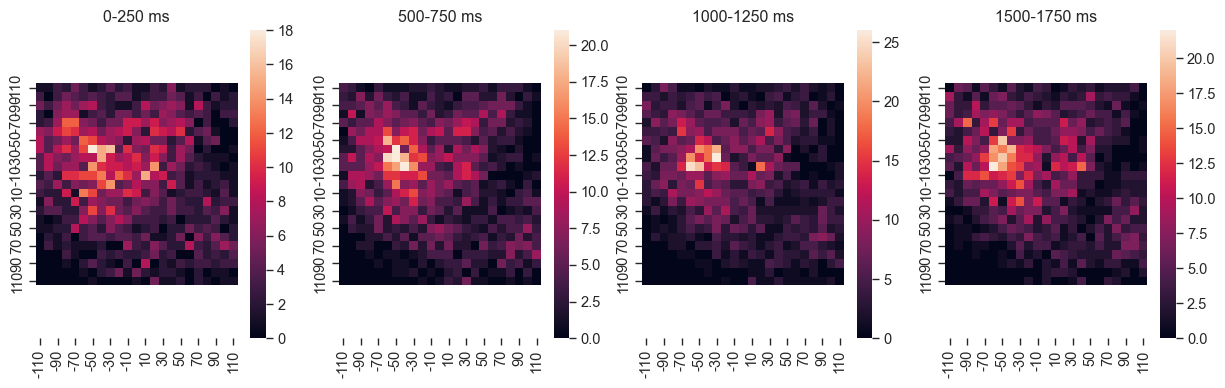

In [73]:
# correction format 2
df_corr = pd.read_csv(r'..\data\results\corrections.csv')

def correct_coordinate(df_corr, df):
    df_new = []
    for subject in df.subject.unique():
        for filename in df.loc[df.subject == subject]['filename'].unique():
            corr_x, corr_y = df_corr.loc[(df_corr.subject == subject) & (df_corr.filename == filename)][['corr_x', 'corr_y']].values[0]
            df_curr = df.loc[(df.subject == subject) & (df.filename == filename)].copy()
            df_curr['x_corr'] = df_curr['gaze_pos_x']+corr_x
            df_curr['y_corr'] = df_curr['gaze_pos_y']+corr_y
            df_new.append(df_curr)
    return pd.concat(df_new, ignore_index=True)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for k in range(0, 8, 2):
    df_activ = correct_coordinate(df_corr, df_activation[k].copy())
    df_activ['x_norm'] = df_activ['x_corr'] - df_activ['pos_x']
    df_activ['y_norm'] = df_activ['y_corr'] - df_activ['pos_y']
    df_map = pd.DataFrame()
    step = 10
    for i in range(-110, 111, step):
        df_map[f'{i}'] = np.zeros(int(110*2//step+1))
    df_map.set_index(np.arange(-110, 111, step), inplace=True)

    x_pos = df_activ['x_norm'].values
    y_pos = df_activ['y_norm'].values
    for i in range(-110, 111, step):
        for j in range(-110, 111, step):
            df_map.loc[df_map.index == j, f'{i}'] = np.where((x_pos >= i-step//2) & (x_pos < i+step//2) & (y_pos >= j-step//2) & (y_pos < j+step//2))[0].shape[0]
    draw_cbar = True#False if k <= 7 else True
    sns.heatmap(df_map, ax=axes[k//2], cbar=draw_cbar)
    axes[k//2].axis('equal')
    axes[k//2].set_title(f'{k*250}-{k*250+250} ms')

### average

In [74]:
subjects = os.listdir(r'..\data\raw\exp')
df_activ = []
for subject in subjects:
    filename = os.path.join(r'..\data\results\gaze_features', f'{subject}_activ.csv')
    df_activ.append(pd.read_csv(filename))
df_activ = pd.concat(df_activ, ignore_index=True)

In [75]:
df_corr = pd.read_csv(r'..\data\results\corrections.csv')

def correct_coordinate(df_corr, df):
    df_new = []
    for subject in df.subject.unique():
        for filename in df.loc[df.subject == subject]['filename'].unique():
            corr_x, corr_y = df_corr.loc[(df_corr.subject == subject) & (df_corr.filename == filename)][['corr_x', 'corr_y']].values[0]
            df_curr = df.loc[(df.subject == subject) & (df.filename == filename)].copy()
            df_curr['x_corr'] = df_curr['gaze_pos_x']+corr_x
            df_curr['y_corr'] = df_curr['gaze_pos_y']+corr_y
            df_new.append(df_curr)
    return pd.concat(df_new, ignore_index=True)

df_activ = correct_coordinate(df_corr, df_activ.copy())

In [77]:
df_activ['x_norm*'] = df_activ['gaze_pos_x'] - df_activ['av_x'] #df_activ['pos_x'] 
df_activ['y_norm*'] = df_activ['gaze_pos_y'] - df_activ['av_y'] #df_activ['pos_y']
df_activ['x_norm**'] = df_activ['x_corr'] - df_activ['pos_x'] #df_activ['pos_x'] 
df_activ['y_norm**'] = df_activ['y_corr'] - df_activ['pos_y'] #df_activ['pos_y']
df_activ['x_norm'] = df_activ['gaze_pos_x'] - df_activ['pos_x'] 
df_activ['y_norm'] = df_activ['gaze_pos_y'] - df_activ['pos_y']
df_activ['radius'] = np.sqrt(df_activ['x_norm'] ** 2 + df_activ['y_norm'] ** 2)

In [629]:
df_activ = df_activ.loc[(df_activ['x_norm*'] < 100) & (df_activ['y_norm*'] < 100)]

In [78]:
df_activ['radius'] = np.sqrt(df_activ['x_norm'] ** 2 + df_activ['y_norm'] ** 2)

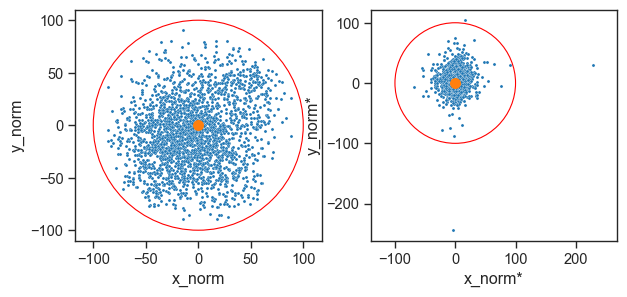

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
sns.scatterplot(df_activ, x='x_norm', y='y_norm', s=5, ax=axes[0])
sns.scatterplot(df_activ, x='x_norm*', y='y_norm*', s=5, ax=axes[1])
for i in range(2):
    axes[i].scatter(x=0, y=0, s=50)
    circle1 = plt.Circle((0, 0), 100, color='r', fill=False)
    axes[i].add_patch(circle1)
    axes[i].axis('equal')

(np.float64(0.0), np.float64(23.0), np.float64(23.0), np.float64(0.0))

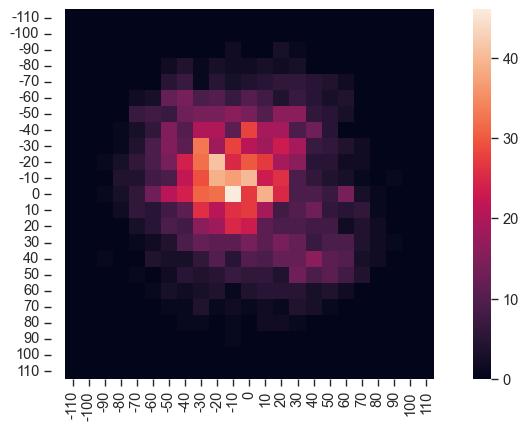

In [80]:
df_map = pd.DataFrame()
step = 10
for i in range(-110, 111, step):
    df_map[f'{i}'] = np.zeros(np.int64(110*2//step+1))
df_map.set_index(np.arange(-110, 111, step), inplace=True)

x_pos = df_activ['x_norm'].values
y_pos = df_activ['y_norm'].values
for i in range(-110, 111, step):
    for j in range(-110, 111, step):
        df_map.loc[df_map.index == j, f'{i}'] = np.where((x_pos >= i-step//2) & (x_pos < i+step//2) & (y_pos >= j-step//2) & (y_pos < j+step//2))[0].shape[0]

sns.heatmap(df_map)
plt.axis('equal')

(np.float64(0.0), np.float64(23.0), np.float64(23.0), np.float64(0.0))

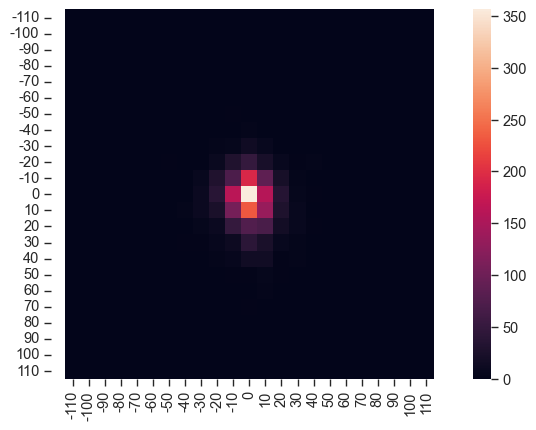

In [81]:
df_map = pd.DataFrame()
step = 10
for i in range(-110, 111, step):
    df_map[f'{i}'] = np.zeros(np.int64(110*2//step+1))
df_map.set_index(np.arange(-110, 111, step), inplace=True)

x_pos = df_activ['x_norm*'].values
y_pos = df_activ['y_norm*'].values
for i in range(-110, 111, step):
    for j in range(-110, 111, step):
        df_map.loc[df_map.index == j, f'{i}'] = np.where((x_pos >= i-step//2) & (x_pos < i+step//2) & (y_pos >= j-step//2) & (y_pos < j+step//2))[0].shape[0]

sns.heatmap(df_map)
plt.axis('equal')

(np.float64(0.0), np.float64(23.0), np.float64(23.0), np.float64(0.0))

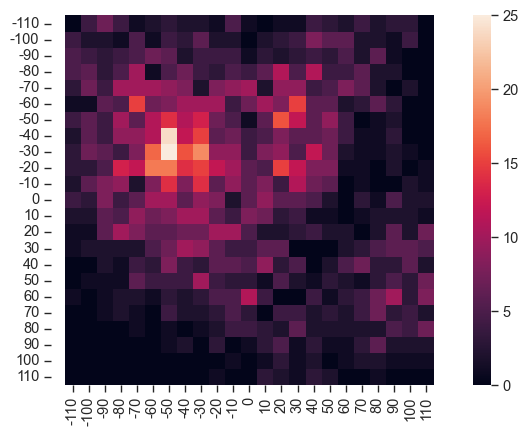

In [82]:
df_map = pd.DataFrame()
step = 10
for i in range(-110, 111, step):
    df_map[f'{i}'] = np.zeros(np.int64(110*2//step+1))
df_map.set_index(np.arange(-110, 111, step), inplace=True)

x_pos = df_activ['x_norm**'].values
y_pos = df_activ['y_norm**'].values
for i in range(-110, 111, step):
    for j in range(-110, 111, step):
        df_map.loc[df_map.index == j, f'{i}'] = np.where((x_pos >= i-step//2) & (x_pos < i+step//2) & (y_pos >= j-step//2) & (y_pos < j+step//2))[0].shape[0]

sns.heatmap(df_map)
plt.axis('equal')

## selection phase: dispersion & deviation & path

In [22]:
subjects = os.listdir(r'..\data\raw\exp')
df_activ = []
for subject in subjects:
    filename = os.path.join(r'..\data\results\gaze_features', f'{subject}_activ.csv')
    df_activ.append(pd.read_csv(filename))
df_activ = pd.concat(df_activ, ignore_index=True)
df_activ = df_activ.loc[(df_activ.p_nan < 50) & (df_activ.subject != '24EK')]

In [29]:
for subject in df_activ.subject.unique():
    status = 'support' if eyetraker_support[subject] == 1 else 'no_support'
    df_activ.loc[df_activ.subject == subject, 'coef_d'] = coef_d[status]

### correction

In [ ]:
df_corr = []
for subject in df_activ.subject.unique():
    for filename in df_activ.loc[df_activ.subject == subject]['filename'].unique():
        df_blast = df_activ.loc[(df_activ.interaction_type == 'blast') & (df_activ.subject == subject) & (df_activ.filename == filename)].copy()
        df_corr.append({
            'subject': subject, 
            'filename': filename,
            'corr_x': (df_blast['av_x'] - df_blast['pos_x']).median().round(2),
            'corr_y': (df_blast['av_y'] - df_blast['pos_y']).median().round(2)
        })
df_corr = pd.DataFrame(df_corr)
# df_corr.to_csv(r'..\data\results\corrections.csv', index=False)

In [103]:
df_corr_all = []
for subject in df_activ.subject.unique():
    for filename in df_activ.loc[df_activ.subject == subject]['filename'].unique():
        df_blast = df_activ.loc[(df_activ.interaction_type == 'blast') & (df_activ.subject == subject) & (df_activ.filename == filename)].copy()
        df_new = pd.DataFrame()
        df_new['corr_x'] =  df_blast['av_x'] - df_blast['pos_x']
        df_new['corr_y'] =  df_blast['av_y'] - df_blast['pos_y']
        df_new['subject'] = subject
        df_new['filename'] = filename
        df_new['n_star'] = df_blast['n_star']
        df_corr_all.append(df_new)
df_corr_all = pd.concat(df_corr_all)

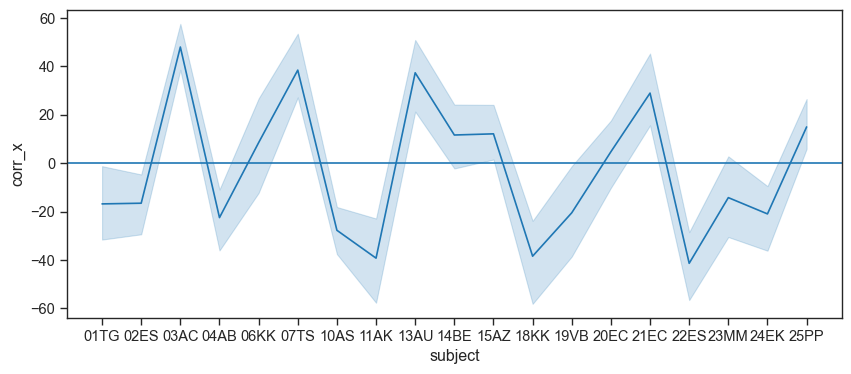

In [114]:
plt.figure(figsize=(10, 4))
sns.lineplot(df_corr_all, x='subject', y='corr_x', estimator=np.mean, errorbar=('pi', 50))
plt.axhline(0)

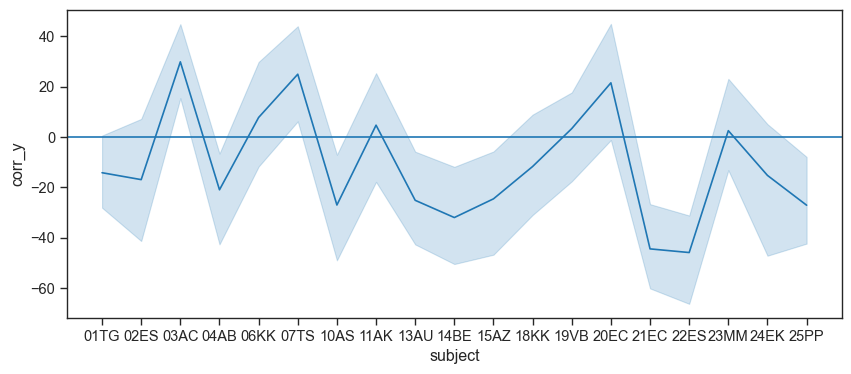

In [115]:
plt.figure(figsize=(10, 4))
sns.lineplot(df_corr_all, x='subject', y='corr_y', estimator=np.mean, errorbar=('pi', 50))
plt.axhline(0)

In [ ]:

for subject in df_corr_all.subject.unique():
    df_subj = df_corr_all.loc[df_corr_all.subject == subject]
    x, y = df_subj['corr_x'].values, df_subj['corr_y'].values
    print(subject)
    print(f"x: mean={np.nanmean(x).round(2)}, std={np.nanstd(x).round(2)}, min={np.nanmin(x).round(2)}, max={np.nanmax(x).round(2)}")
    print(f"y: mean={np.nanmean(y).round(2)}, std={np.nanstd(y).round(2)}, min={np.nanmin(y).round(2)}, max={np.nanmax(y).round(2)}")


01TG
x: mean=-16.85, std=22.1, min=-75.5, max=32.0
y: mean=-14.17, std=20.19, min=-63.4, max=36.55
02ES
x: mean=-16.57, std=18.3, min=-61.1, max=22.6
y: mean=-16.92, std=31.67, min=-78.5, max=64.2
03AC
x: mean=48.02, std=15.73, min=-6.9, max=91.9
y: mean=29.82, std=20.54, min=-20.9, max=72.9
04AB
x: mean=-22.52, std=21.55, min=-78.0, max=21.55
y: mean=-20.95, std=30.08, min=-75.9, max=46.6
06KK
x: mean=8.47, std=29.22, min=-62.4, max=77.0
y: mean=7.75, std=31.35, min=-65.9, max=63.55
07TS
x: mean=38.46, std=22.98, min=-32.1, max=76.1
y: mean=24.91, std=27.85, min=-45.7, max=71.4
10AS
x: mean=-27.76, std=19.88, min=-77.1, max=48.3
y: mean=-26.99, std=25.98, min=-82.5, max=23.9
11AK
x: mean=-39.29, std=25.03, min=-101.5, max=27.6
y: mean=4.69, std=27.82, min=-55.0, max=61.1
13AU
x: mean=37.37, std=20.56, min=-8.1, max=91.35
y: mean=-25.12, std=29.24, min=-88.5, max=30.9
14BE
x: mean=11.63, std=18.12, min=-25.7, max=55.1
y: mean=-31.96, std=24.74, min=-93.4, max=19.2
15AZ
x: mean=12.12, s

(np.float64(-64.375),
 np.float64(71.475),
 np.float64(-69.45),
 np.float64(59.25))

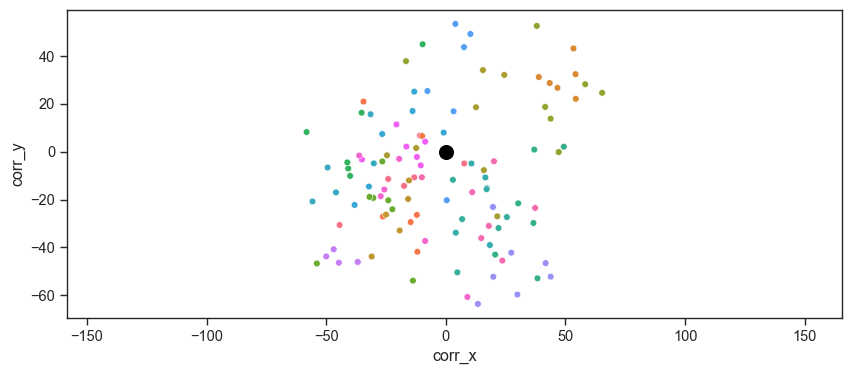

In [102]:
plt.figure(figsize=(10, 4))
# sns.boxplot(df_corr, x='subject', y='corr_x')
# sns.boxplot(df_corr, x='subject', y='corr_y')
sns.scatterplot(df_corr, x='corr_x', y='corr_y', hue='subject', legend=False)
plt.scatter(0, 0, s=100, color='black')
plt.axis('equal')

In [106]:
df_subj

,corr_x,corr_y,subject,filename,n_star
2359,NaN,NaN,25PP,im_log_game_1,5
2360,NaN,NaN,25PP,im_log_game_1,18
2361,21.00,-53.65,25PP,im_log_game_1,2
2362,-6.40,-26.30,25PP,im_log_game_1,13
2363,4.10,9.10,25PP,im_log_game_1,7
...,...,...,...,...,...
2472,14.55,-36.80,25PP,qm_log_game_4,5
2474,56.30,-48.70,25PP,qm_log_game_4,3
2475,28.50,-20.10,25PP,qm_log_game_4,10
2476,40.60,-42.30,25PP,qm_log_game_4,0


### main

In [13]:
df_activ['x_norm'] = df_activ['gaze_pos_x'] - df_activ['pos_x']
df_activ['y_norm'] = df_activ['gaze_pos_y'] - df_activ['pos_y']
df_activ['radius'] = np.sqrt(df_activ['x_norm'] ** 2 + df_activ['y_norm'] ** 2)

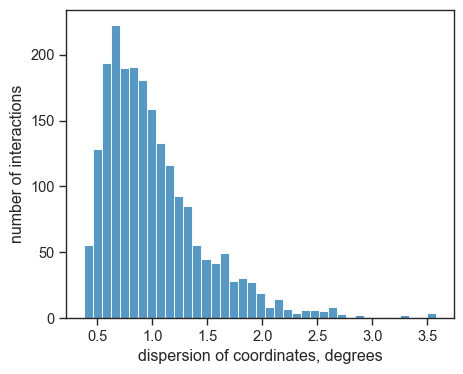

In [37]:
df_range = df_activ.loc[(df_activ.range > df_activ.range.quantile(0.025)) & (df_activ.range < df_activ.range.quantile(0.975))]
df_range['range_d'] = np.multiply(df_range['range'].values, df_range['coef_d'].values)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_range, x='range_d', ax=ax)
ax.set_xlabel('dispersion of coordinates, degrees')
ax.set_ylabel('number of interactions');

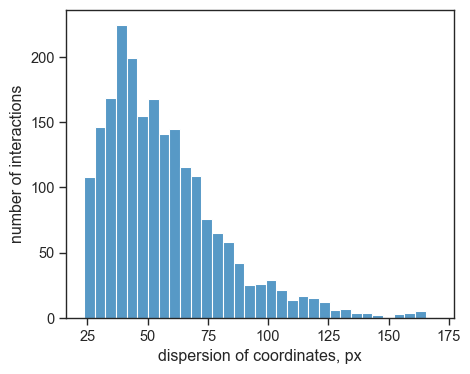

In [35]:
df_range = df_activ.loc[(df_activ.range > df_activ.range.quantile(0.025)) & (df_activ.range < df_activ.range.quantile(0.975))]
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_range, x='range', ax=ax)
ax.set_xlabel('dispersion of coordinates, px')
ax.set_ylabel('number of interactions');

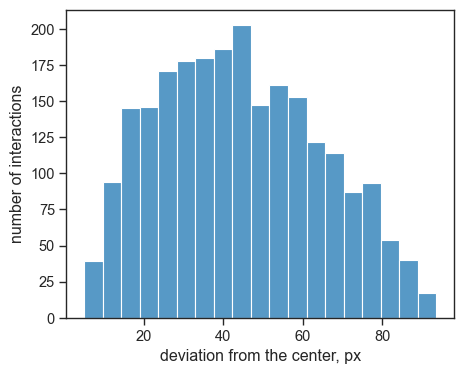

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_activ, x='deviation', ax=ax)
ax.set_xlabel('deviation from the center, px')
ax.set_ylabel('number of interactions');
# ax.set_xlim(0, 5000)

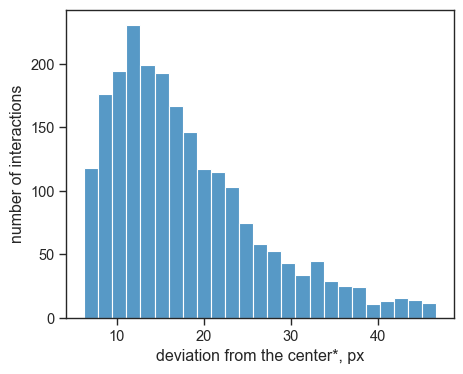

In [6]:
df_dev = df_activ.loc[(df_activ.norm_dev > df_activ.norm_dev.quantile(0.025)) & (df_activ.norm_dev < df_activ.norm_dev.quantile(0.975))]
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_dev, x='norm_dev', ax=ax)
ax.set_xlabel('deviation from the center*, px')
ax.set_ylabel('number of interactions');
# ax.set_xlim(0, 5000)

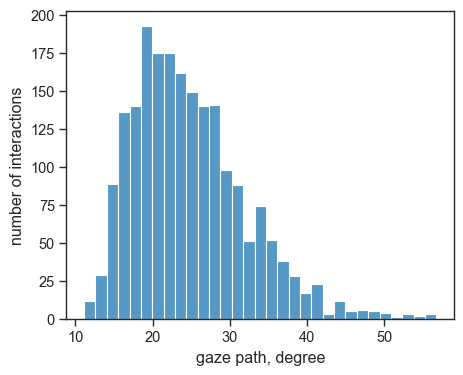

In [39]:
df_dev = df_activ.loc[(df_activ.gaze_path > df_activ.gaze_path.quantile(0.025)) & (df_activ.gaze_path < df_activ.gaze_path.quantile(0.975))]
df_dev['gaze_path_d'] = np.multiply(df_dev['gaze_path'].values, df_dev['coef_d'].values)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_dev, x='gaze_path_d', ax=ax)
ax.set_xlabel('gaze path, degree')
ax.set_ylabel('number of interactions');
# ax.set_xlim(0, 5000)

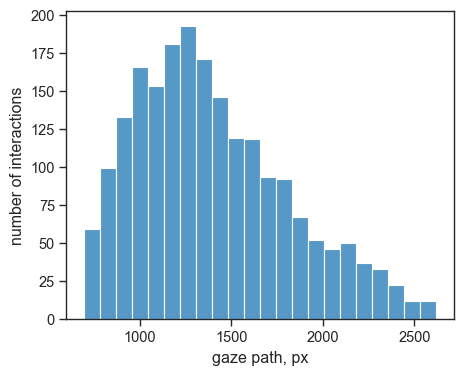

In [40]:
df_dev = df_activ.loc[(df_activ.gaze_path > df_activ.gaze_path.quantile(0.025)) & (df_activ.gaze_path < df_activ.gaze_path.quantile(0.975))]
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_dev, x='gaze_path', ax=ax)
ax.set_xlabel('gaze path, px')
ax.set_ylabel('number of interactions');
# ax.set_xlim(0, 5000)

## selection phase: fixations & saccades

events BEFORE interaction start (before yellow light)

In [5]:
subjects = os.listdir(r'..\data\raw\exp')
df_events = []
for subject in subjects:
    filename = os.path.join(r'..\data\results\gaze_features', f'{subject}_events.csv')
    df_events.append(pd.read_csv(filename))
df_events = pd.concat(df_events, ignore_index=True)
df_events['dur'] = df_events['time_end'] - df_events['time_start']
df_fix = df_events.loc[df_events.event == 'fixation'].copy()
# df_fix = df_fix.loc[(df_fix.dur > df_fix.dur.quantile(0.025)) & (df_fix.dur < df_fix.dur.quantile(0.975))]

In [6]:
df_max = []
for res in df_fix.res_timestamp.unique():
    df_start = df_fix.loc[(df_fix.res_timestamp == res) & (df_fix.res_start >= res - 2000) & (df_fix.res_end <= res)].copy()
    # if len(df_start) == 0:
    #     print(res)
    max_dur = df_start.dur.max()
    df_max.append(df_start[df_start.dur == max_dur])
df_max = pd.concat(df_max, ignore_index=False)

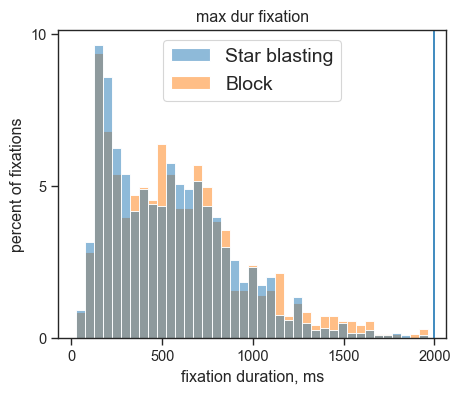

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_max, x='dur', hue='interaction_type', ax=ax, stat='percent', common_norm=False, binwidth=50)
ax.axvline(2000)
ax.set_xlabel('fixation duration, ms')
ax.set_ylabel('percent of fixations');
ax.set_yticks([0, 5, 10])
ax.set_title('max dur fixation')
ax.legend(ax.get_legend().legend_handles, ['Star blasting', 'Block'], fontsize=14)
plt.savefig(r'..\data\results\pic_ETRA\max_dur_fixation.png', dpi=300)
# ax.set_xlim(0, 5000)

In [15]:
df_all = []
for res in df_fix.res_timestamp.unique():
    df_start = df_fix.loc[(df_fix.res_timestamp == res) & (df_fix.res_start >= res - 2000) & (df_fix.res_end <= res)].copy()
    if len(df_start) != 0:
        max_dur = df_start.dur.values[0]
        df_all.append(df_start[df_start.dur == max_dur])
df_all = pd.concat(df_all, ignore_index=False)
df_all

,time_start,time_end,x_average,y_average,event,x_start,y_start,x_stop,y_stop,res_start,res_end,interaction_type,res_timestamp,condition,n_game,subject,filename,n_star,n,dur
0,4698416.0,4698822.0,904.3,510.9,fixation,NaN,NaN,NaN,NaN,418387863.0,418388269.0,blast,418389862,im,1,01TG,im_log_game_1,9,1,406.0
7,4724416.0,4725362.0,569.1,877.6,fixation,NaN,NaN,NaN,NaN,418413863.0,418414809.0,blast,418415734,im,1,01TG,im_log_game_1,1,3,946.0
14,4750258.0,4750468.0,707.3,685.8,fixation,NaN,NaN,NaN,NaN,418439705.0,418439915.0,blast,418441671,im,1,01TG,im_log_game_1,4,5,210.0
22,4766536.0,4766686.0,877.6,262.6,fixation,NaN,NaN,NaN,NaN,418455983.0,418456133.0,blast,418457940,im,1,01TG,im_log_game_1,7,6,150.0
28,4778870.0,4779992.0,631.1,237.1,fixation,NaN,NaN,NaN,NaN,418468317.0,418469439.0,blast,418470264,im,1,01TG,im_log_game_1,2,7,1122.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,2614532.0,2614760.0,707.1,542.4,fixation,NaN,NaN,NaN,NaN,5061031.0,5061259.0,blast,5062802,qm,3,25PP,qm_log_game_4,3,16,228.0
15425,2628988.0,2629170.0,986.1,484.1,fixation,NaN,NaN,NaN,NaN,5075487.0,5075669.0,blast,5077122,qm,3,25PP,qm_log_game_4,10,17,182.0
15438,2642190.0,2642622.0,617.2,739.1,fixation,NaN,NaN,NaN,NaN,5088689.0,5089121.0,blast,5090484,qm,3,25PP,qm_log_game_4,0,18,432.0
15446,2656314.0,2656576.0,1077.7,652.2,fixation,NaN,NaN,NaN,NaN,5102813.0,5103075.0,blast,5104802,qm,3,25PP,qm_log_game_4,12,19,262.0


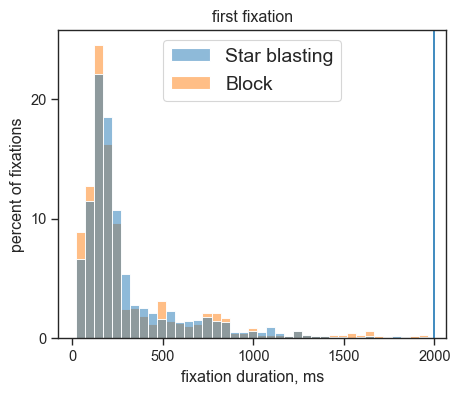

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_all, x='dur', hue='interaction_type', ax=ax, stat='percent', common_norm=False, binwidth=50)
ax.axvline(2000)
ax.set_yticks([0, 10, 20])
ax.set_xlabel('fixation duration, ms')
ax.set_ylabel('percent of fixations');
ax.set_title('first fixation')
ax.legend(ax.get_legend().legend_handles, ['Star blasting', 'Block'], fontsize=14)
# ax.set_xlim(0, 5000)
plt.savefig(r'..\data\results\pic_ETRA\first_fixation.png', dpi=300)

In [535]:
df_events['amplitude'] = np.sqrt((df_events['x_stop'] - df_events['x_start']) ** 2 + (df_events['y_stop'] - df_events['y_start']) ** 2)
df_sac = df_events.copy()
df_sac.loc[df_sac.event == 'fixation', 'amplitude'] = -1
df_sac = df_sac.loc[(df_sac.amplitude == -1) | (df_sac.amplitude > df_sac.amplitude.quantile(0.025)) & (df_sac.amplitude < df_sac.amplitude.quantile(0.975))]
df_amp = []
for subject in df_events.subject.unique():
    for condition in ['im', 'qm']:
        for n_game in df_sac[(df_sac.subject == subject) & (df_sac.condition == condition)]['n_game'].unique():
            df_curr = df_sac.loc[(df_sac.subject == subject) & (df_sac.condition == condition) & (df_sac.n_game == n_game)]
            for int in df_curr.n.unique():
                df_star = df_curr.loc[(df_curr.n == int) & (df_curr.event == 'saccade')]
                sum_amp = df_star.amplitude.sum() if len(df_star) != 0 else 0
                df_amp.append({'subject' : subject, 'condition': condition, 'n_game': n_game,
                               'n': int, 'amp': sum_amp})
df_amp = pd.DataFrame(df_amp)

In [545]:
df_amp.loc[df_amp.amp < 50].shape[0] / df_amp.shape[0]

0.3774778574441164

(-3.0, 700.0)

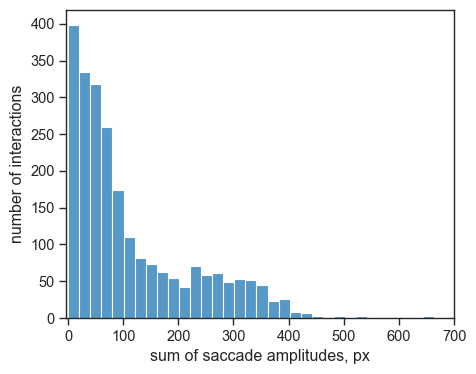

In [549]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
sns.histplot(df_amp, x='amp', ax=ax)
ax.set_xlabel('sum of saccade amplitudes, px')
ax.set_ylabel('number of interactions');
ax.set_xlim(-3, 700)

## timecourse

In [ ]:
subjects = os.listdir(r'..\data\raw\exp')
df_steps = []
for subject in subjects:
    filename = os.path.join(r'..\data\results\gaze_features', f'{subject}_steps.csv')
    df_steps.append(pd.read_csv(filename))
df_steps = pd.concat(df_steps, ignore_index=True)
df_steps = df_steps.loc[(df_steps.p_nan < 50) & (df_steps.subject != '24EK')]
for subject in df_steps.subject.unique():
    status = 'support' if eyetraker_support[subject] == 1 else 'no_support'
    df_steps.loc[df_steps.subject == subject, 'coef_d'] = coef_d[status]

In [45]:
for subject in df_steps.subject.unique():
    status = 'support' if eyetraker_support[subject] == 1 else 'no_support'
    df_steps.loc[df_steps.subject == subject, 'coef_d'] = coef_d[status]

### deviation

In [12]:
df_dev = df_steps.loc[(df_steps.deviation > df_steps.deviation.quantile(.025)) & (df_steps.deviation < df_steps.deviation.quantile(.975))]

In [124]:
df_artem = df_dev[['subject', 'condition', 'n_game', 'event', 'n_step', 'deviation', 'norm_dev']]
df_artem.to_csv(r'..\data\results\artem_deviation.csv', index=False)

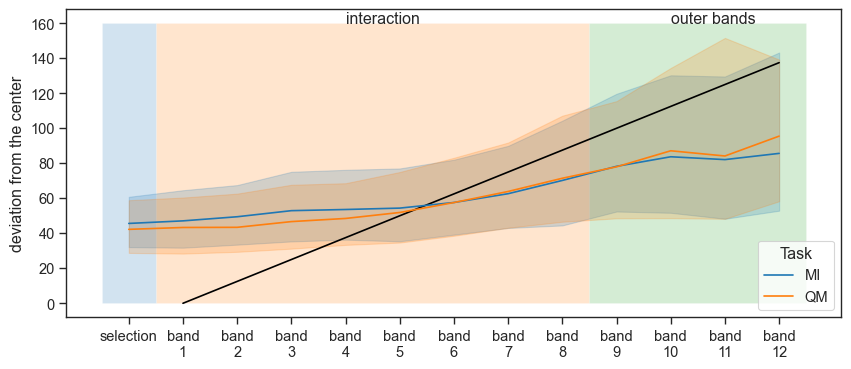

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
ax.fill_between([0.5, 1.5], 0, 160, alpha=.2)
ax.text(5, 160, 'interaction')
ax.text(11, 160, 'outer bands')
ax.fill_between(np.arange(1.5, 10.5), 0, 160, alpha=.2)
ax.fill_between(np.arange(9.5, 14.5), 0, 160, alpha=.2)
ax.plot(np.arange(2, 14), np.arange(0, 12.5*12, 12.5), 'black')
sns.lineplot(df_dev, x='n_step', y='deviation', hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
# ax.axvline(2000)
ax.set_xlabel('')
ax.set_xticks(np.arange(1, 14), ['selection'] + [f'band\n{i}' for i in range(1, 13)])
ax.set_ylabel('deviation from the center');
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')


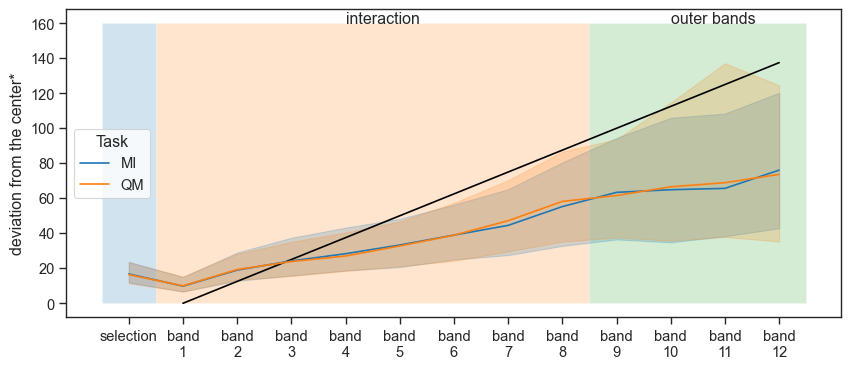

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
ax.fill_between([0.5, 1.5], 0, 160, alpha=.2)
ax.text(5, 160, 'interaction')
ax.text(11, 160, 'outer bands')
ax.fill_between(np.arange(1.5, 10.5), 0, 160, alpha=.2)
ax.fill_between(np.arange(9.5, 14.5), 0, 160, alpha=.2)
ax.plot(np.arange(2, 14), np.arange(0, 12.5*12, 12.5), 'black')
sns.lineplot(df_dev, x='n_step', y='norm_dev', hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
# ax.axvline(2000)
ax.set_xlabel('')
ax.set_xticks(np.arange(1, 14), ['selection'] + [f'band\n{i}' for i in range(1, 13)])
ax.set_ylabel('deviation from the center*');
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')

### range and dev

In [ ]:
df_range = df_steps.loc[(df_steps.range > df_steps.range.quantile(.025)) & (df_steps.range < df_steps.range.quantile(.975))]
df_gaze_path = df_steps.loc[(df_steps.gaze_path > df_steps.gaze_path.quantile(.025)) & (df_steps.gaze_path < df_steps.gaze_path.quantile(.975))]

In [79]:
df_range = df_range.loc[df_range.event != 'overkill_step']
df_gaze_path = df_gaze_path.loc[df_gaze_path.event != 'overkill_step']

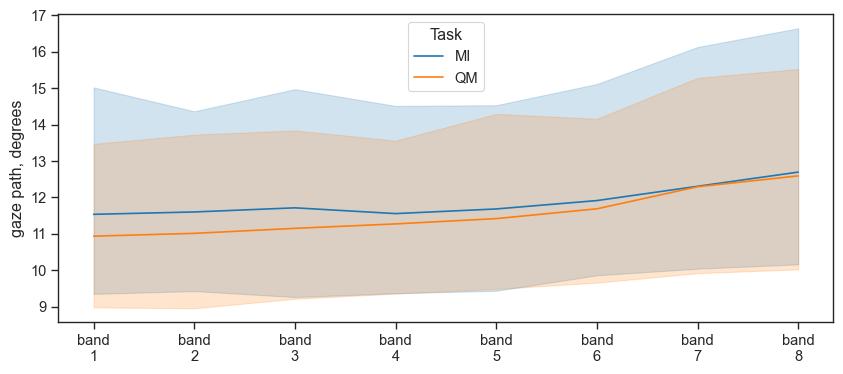

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.set_style("ticks")
max_band = 10
sns.set_context("paper", font_scale=1.2)
df_gaze_path['gaze_path_d'] = np.multiply(df_gaze_path['gaze_path'].values, df_gaze_path['coef_d'].values)
sns.lineplot(df_gaze_path.loc[df_gaze_path.n_step.isin(np.arange(2, max_band))], x='n_step', y='gaze_path_d', hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
# ax.axvline(2000)
ax.set_xlabel('')
ax.set_xticks(np.arange(2, max_band),  [f'band\n{i}' for i in range(1, max_band-1)])
ax.set_ylabel('gaze path, degrees');
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
# ax.set_ylim(500, 800)

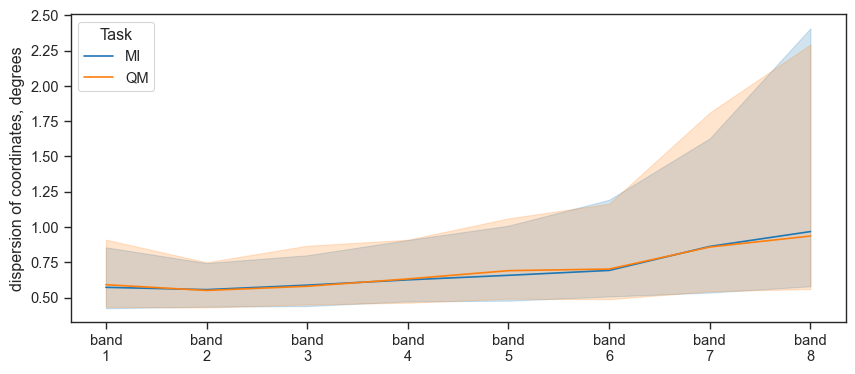

In [81]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.set_style("ticks")
max_band = 10
sns.set_context("paper", font_scale=1.2)
df_range['range_d'] = np.multiply(df_range['range'].values, df_range['coef_d'].values)
sns.lineplot(df_range.loc[df_range.n_step.isin(np.arange(2, max_band))], x='n_step', y='range_d', hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
# ax.axvline(2000)
ax.set_xlabel('')
ax.set_xticks(np.arange(2, max_band), [f'band\n{i}' for i in range(1, max_band-1)])
ax.set_ylabel('dispersion of coordinates, degrees');
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
# ax.set_xlim(2, 8)

# ax.set_ylim(0,100)

(0.0, 150.0)

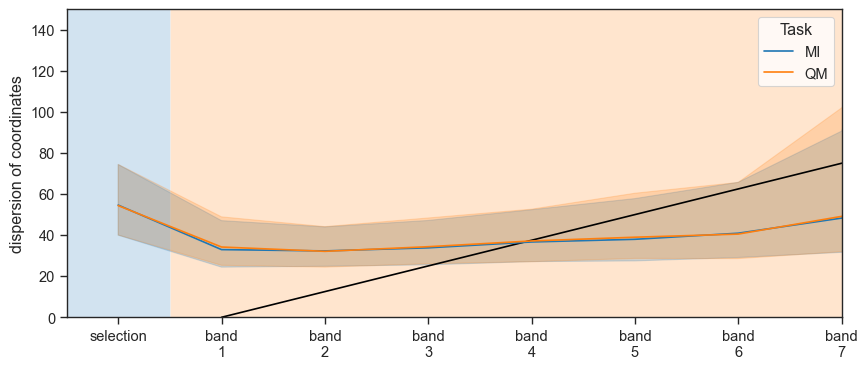

In [55]:
df_range = df_steps.loc[(df_steps.range > df_steps.range.quantile(.025)) & (df_steps.range < df_steps.range.quantile(.975))]
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
ax.fill_between([0.5, 1.5], 0, 160, alpha=.2)
# ax.text(5, 160, 'interaction')
# ax.text(11, 160, 'outer bands')
ax.fill_between(np.arange(1.5, 10.5), 0, 160, alpha=.2)
ax.fill_between(np.arange(9.5, 14.5), 0, 160, alpha=.2)
ax.plot(np.arange(2, 14), np.arange(0, 12.5*12, 12.5), 'black')
sns.lineplot(df_range, x='n_step', y='range', hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
# ax.axvline(2000)
ax.set_xlabel('')
ax.set_xticks(np.arange(1, 14), ['selection'] + [f'band\n{i}' for i in range(1, 13)])
ax.set_ylabel('dispersion of coordinates');
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
ax.set_xlim(0.5, 8)
ax.set_ylim(0, 150)

(0.0, 200.0)

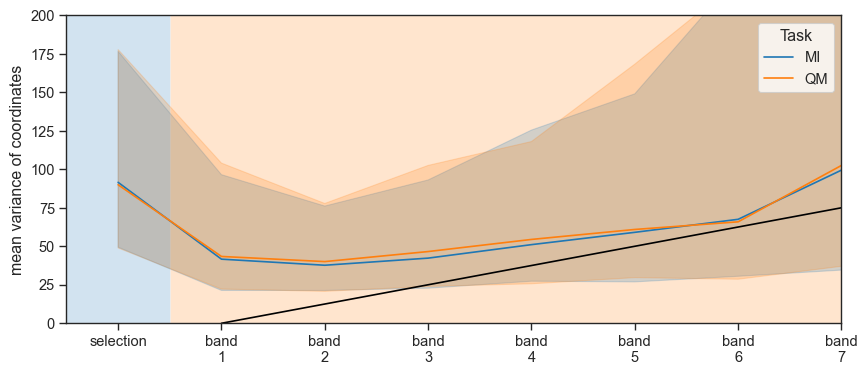

In [57]:
metric = 'var'
df_range = df_steps.loc[(df_steps[metric] > df_steps[metric].quantile(.025)) & (df_steps[metric] < df_steps[metric].quantile(.975))]
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
ax.fill_between([0.5, 1.5], 0, 200, alpha=.2)
# ax.text(5, 160, 'interaction')
# ax.text(11, 160, 'outer bands')
ax.fill_between(np.arange(1.5, 10.5), 0, 200, alpha=.2)
ax.fill_between(np.arange(9.5, 14.5), 0, 160, alpha=.2)
ax.plot(np.arange(2, 14), np.arange(0, 12.5*12, 12.5), 'black')
sns.lineplot(df_range, x='n_step', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
# ax.axvline(2000)
ax.set_xlabel('')
ax.set_xticks(np.arange(1, 14), ['selection'] + [f'band\n{i}' for i in range(1, 13)])
ax.set_ylabel('mean variance of coordinates');
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
ax.set_xlim(0.5, 8)
ax.set_ylim(0, 200)

### windows

In [23]:
subjects = os.listdir(r'..\data\raw\exp')
df_steps = []
for subject in subjects:
    filename = os.path.join(r'..\data\results\gaze_features', f'{subject}_steps.csv')
    df_steps.append(pd.read_csv(filename))
df_steps = pd.concat(df_steps, ignore_index=True)
df_steps = df_steps.loc[(df_steps.p_nan < 50) & (df_steps.subject != '24EK')]
for subject in df_steps.subject.unique():
    status = 'support' if eyetraker_support[subject] == 1 else 'no_support'
    df_steps.loc[df_steps.subject == subject, 'coef_d'] = coef_d[status]
df_steps = df_steps.loc[df_steps.n_blast == 8]

In [24]:
df_steps.loc[df_steps.window >= 10000][['condition', 'window']].value_counts(sort=False)

condition  window
im         10000     609
           10500     611
           11000     601
           11500     278
           12000     274
           12500     118
           13000     118
           13500      66
           14000      65
qm         10000     574
           10500     576
           11000     561
           11500     268
           12000     266
           12500     125
           13000     125
           13500      53
           14000      55
Name: count, dtype: int64

In [25]:
df_steps['window'].value_counts(sort=False)

window
500      1181
1000     1183
1500     1185
2000     1185
2500     1186
3000     1187
3500     1186
4000     1187
4500     1188
5000     1185
5500     1187
6000     1188
6500     1189
7000     1189
7500     1191
8000     1188
8500     1189
9000     1188
9500     1190
10000    1183
10500    1187
11000    1162
11500     546
12000     540
12500     243
13000     243
13500     119
14000     120
Name: count, dtype: int64

In [26]:
# df_steps = df_steps.loc[df_steps.step != 'overkill']
# df_steps = df_steps.loc[(df_steps.window <= 11000)]

In [27]:
df_steps['gaze_path_d'] = np.multiply(df_steps['gaze_path'].values, df_steps['coef_d'].values)
df_steps['range_d'] = np.multiply(df_steps['range'].values, df_steps['coef_d'].values)
df_steps['dev_d'] = np.multiply(df_steps['deviation'].values, df_steps['coef_d'].values)
df_steps['norm_dev_d'] = np.multiply(df_steps['norm_dev'].values, df_steps['coef_d'].values)

In [28]:
df_range = df_steps.loc[(df_steps.range_d > df_steps.range_d.quantile(.025)) & (df_steps.range_d < df_steps.range_d.quantile(.975))]
df_gaze_path = df_steps.loc[(df_steps.gaze_path_d > df_steps.gaze_path_d.quantile(.025)) & (df_steps.gaze_path_d < df_steps.gaze_path_d.quantile(.975))]
df_dev = df_steps.loc[(df_steps.dev_d > df_steps.dev_d.quantile(.025)) & (df_steps.dev_d < df_steps.dev_d.quantile(.975))]
df_norm_dev = df_steps.loc[(df_steps.norm_dev_d > df_steps.norm_dev_d.quantile(.025)) & (df_steps.norm_dev_d < df_steps.norm_dev_d.quantile(.975))]

In [29]:
df_norm_dev.loc[df_norm_dev.window >= 10000][['condition', 'window']].value_counts(sort=False)

condition  window
im         10000     557
           10500     541
           11000     509
           11500     236
           12000     222
           12500      98
           13000      97
           13500      58
           14000      58
qm         10000     538
           10500     531
           11000     494
           11500     239
           12000     235
           12500     105
           13000     101
           13500      40
           14000      45
Name: count, dtype: int64

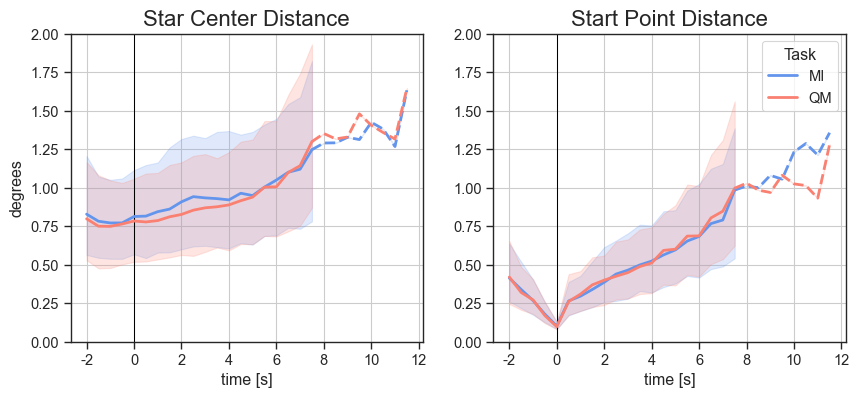

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
user_palette = {'im': 'cornflowerblue', 'qm': 'salmon'}
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
ax = axes[0]
# ax.grid()
metric = 'dev_d'
# ax.plot([2500, 10500], [0, 2], '--', color='black', linewidth=.5)
ax.axvline(2500, linewidth=.75, color='black')
ax.grid()
# ax.axvline(10500, linewidth=.5)
sns.lineplot(df_dev.loc[df_dev.window <= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax,
             linewidth=2, legend=False, palette=user_palette)
sns.lineplot(df_dev.loc[df_dev.window >= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 0), ax=ax, 
             linewidth=2, linestyle='--', legend=False, palette=user_palette)
ax.set_xlabel('time [s]')
ax.set_title('Star Center Distance', fontsize=16);
ax.set_ylabel('degrees')
ax.set_ylim(0, 2)

# ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
ax.set_xticks(np.arange(500, 14501, 2000), np.arange(-2, 12.5, 2).astype(int))

ax = axes[1]
metric = 'norm_dev_d'
# ax.plot([2500, 10500], [median_cent_dev, median_cent_dev+2], '--', color='black', linewidth=.5)
ax.axvline(2500, linewidth=.75, color='black')
ax.grid()
# ax.axvline(10500, linewidth=.5)
sns.lineplot(df_norm_dev.loc[df_norm_dev.window <= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax,
             linewidth=2, palette=user_palette)
sns.lineplot(df_norm_dev.loc[df_norm_dev.window >= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 0), ax=ax, 
             linestyle='--', linewidth=2, palette=user_palette)
ax.set_xlabel('time [s]')
ax.set_title('Start Point Distance', fontsize=16);
ax.set_ylabel('')
ax.set_ylim(0, 2)

ax.set_xticks(np.arange(500, 14501, 2000), np.arange(-2, 12.5, 2).astype(int))
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')

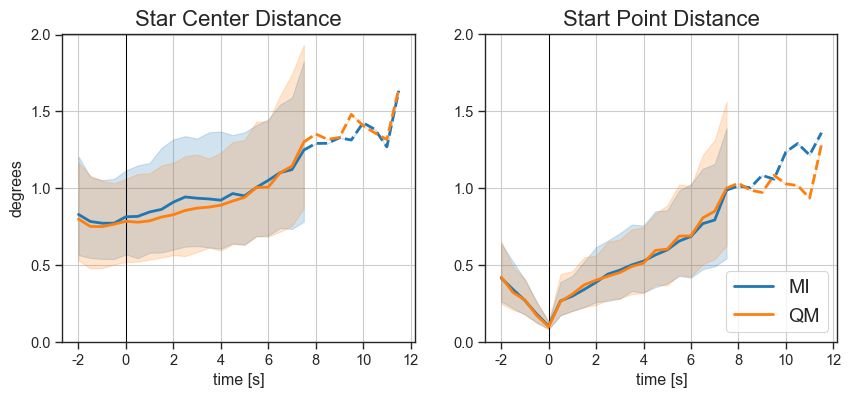

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# user_palette = {'im': 'cornflowerblue', 'qm': 'salmon'}
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
ax = axes[0]
# ax.grid()
metric = 'dev_d'
# ax.plot([2500, 10500], [0, 2], '--', color='black', linewidth=.5)
ax.axvline(2500, linewidth=.75, color='black')
ax.grid()
# ax.axvline(10500, linewidth=.5)
sns.lineplot(df_dev.loc[df_dev.window <= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax,
             linewidth=2, legend=False)
sns.lineplot(df_dev.loc[df_dev.window >= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 0), ax=ax, 
             linewidth=2, linestyle='--', legend=False)
ax.set_xlabel('time [s]')
ax.set_title('Star Center Distance', fontsize=16);
ax.set_ylabel('degrees')
ax.set_yticks([0, 0.5, 1, 1.5, 2])

# ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
ax.set_xticks(np.arange(500, 14501, 2000), np.arange(-2, 12.5, 2).astype(int))

ax = axes[1]
metric = 'norm_dev_d'
# ax.plot([2500, 10500], [median_cent_dev, median_cent_dev+2], '--', color='black', linewidth=.5)
ax.axvline(2500, linewidth=.75, color='black')
ax.grid()
# ax.axvline(10500, linewidth=.5)
sns.lineplot(df_norm_dev.loc[df_norm_dev.window <= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax,
             linewidth=2)
sns.lineplot(df_norm_dev.loc[df_norm_dev.window >= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 0), ax=ax, 
             linestyle='--', linewidth=2)
ax.set_xlabel('time [s]')
ax.set_title('Start Point Distance', fontsize=16);
ax.set_ylabel('')
ax.set_yticks([0, 0.5, 1, 1.5, 2])

ax.set_xticks(np.arange(500, 14501, 2000), np.arange(-2, 12.5, 2).astype(int))
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], fontsize=14)


plt.savefig(r'..\data\results\pic_ETRA\deviation.png', dpi=300)

(0.2, 3.0)

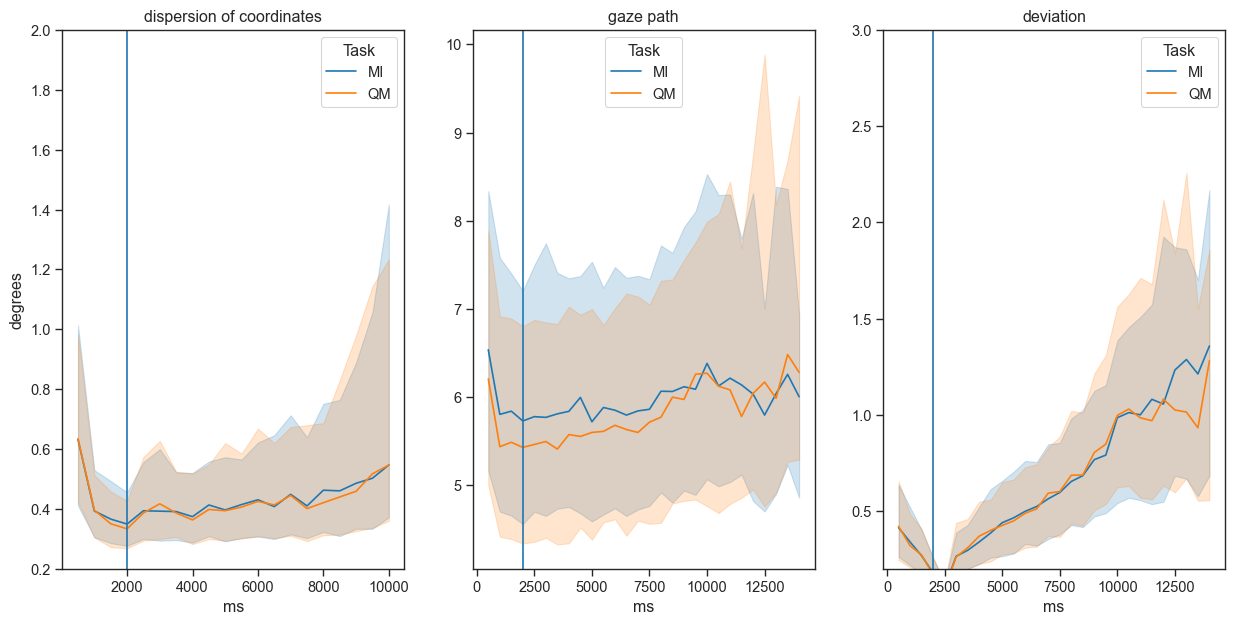

In [35]:
metric = 'range_d'
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.2)
ax = axes[0]
sns.lineplot(df_range.loc[df_range.window <= 10000], x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
ax.set_xlabel('ms')
ax.set_ylabel('degrees')
ax.set_title('dispersion of coordinates');
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
ax.axvline(2000)
ax.set_ylim(0.2, 2)
metric = 'gaze_path_d'
ax = axes[1]
sns.lineplot(df_gaze_path, x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
ax.set_xlabel('ms')
ax.set_title('gaze path');
ax.set_ylabel('')
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
ax.axvline(2000)
# ax.set_ylim(0.2, 2)
metric = 'norm_dev_d'
ax = axes[2]
sns.lineplot(df_norm_dev, x='window', y=metric, hue='condition', estimator=np.nanmedian, errorbar=('pi', 50), ax=ax)
ax.set_xlabel('ms')
ax.set_title('deviation');
ax.set_ylabel('')
ax.legend(ax.get_legend().legend_handles, ['MI', 'QM'], title='Task')
ax.axvline(2000)
ax.set_ylim(0.2, 3)